# Naive Bayes

## Data Prep

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load data
df = pd.read_csv("soviet_breakdown_dataset.csv")

# Re-add region
regions_map = {
    'Estonia': 'Baltics', 'Latvia': 'Baltics', 'Lithuania': 'Baltics',
    'Russia': 'Eastern Europe', 'Ukraine': 'Eastern Europe',
    'Belarus': 'Eastern Europe', 'Moldova': 'Eastern Europe',
    'Kazakhstan': 'Central Asia', 'Uzbekistan': 'Central Asia',
    'Turkmenistan': 'Central Asia', 'Kyrgyzstan': 'Central Asia',
    'Tajikistan': 'Central Asia', 'Armenia': 'Caucasus',
    'Azerbaijan': 'Caucasus', 'Georgia': 'Caucasus'
}
df['Region'] = df['Country'].map(regions_map)

# Drop rows with missing values
df = df.dropna(subset=['GDP_Per_Capita', 'Military_Exp_Percent_GDP'])

# ---- CREATE THE LABEL ----
# Binary label: 1 = High Performer (above median GDP), 0 = Low Performer
median_gdp = df['GDP_Per_Capita'].median()
df['Label'] = (df['GDP_Per_Capita'] >= median_gdp).astype(int)

# ---- ENCODE CATEGORICALS ----
le_period = LabelEncoder()
le_region = LabelEncoder()
df['Period_Enc'] = le_period.fit_transform(df['Period'])
df['Region_Enc'] = le_region.fit_transform(df['Region'])

# ---- FEATURE SET ----
# Features we will use (all quantitative or encoded)
X = df[['Military_Exp_Percent_GDP', 'Year', 'Period_Enc', 'Region_Enc']]
y = df['Label']

# ---- TRAIN/TEST SPLIT (80/20) ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- NORMALIZE (for Gaussian NB) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save datasets for your website screenshots
X_train.to_csv('nb_X_train.csv', index=False)
X_test.to_csv('nb_X_test.csv', index=False)
df[['Military_Exp_Percent_GDP', 'Year', 'Period_Enc', 'Region_Enc', 'Label']].to_csv('nb_full_labeled.csv', index=False)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Label distribution:\n", y.value_counts())

Training set shape: (308, 4)
Testing set shape: (77, 4)
Label distribution:
 Label
1    193
0    192
Name: count, dtype: int64


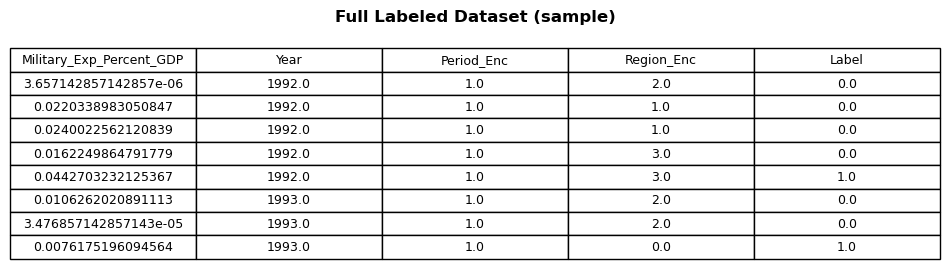

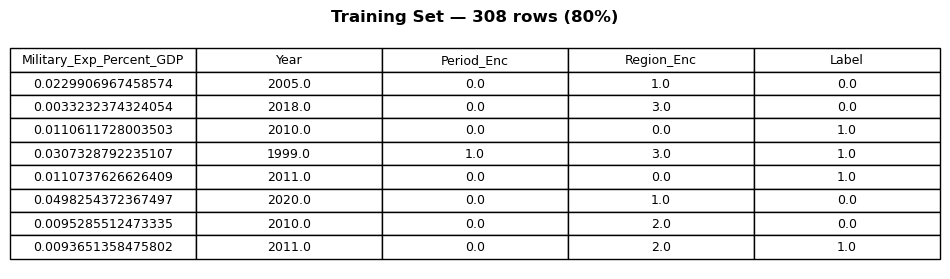

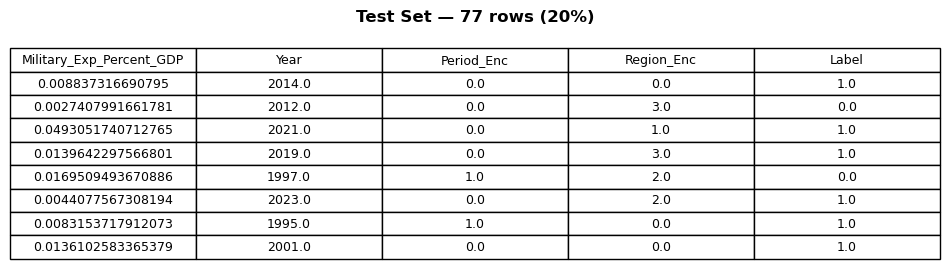

Training rows: 308, Test rows: 77


In [4]:
import matplotlib.pyplot as plt

# ---- SCREENSHOT 1: Full Labeled Dataset (head) ----
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
full_sample = pd.read_csv('nb_full_labeled.csv').head(8)
table = ax.table(cellText=full_sample.values,
                 colLabels=full_sample.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
plt.title('Full Labeled Dataset (sample)', fontweight='bold', pad=12)
plt.savefig('nb_full_dataset_screenshot.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- SCREENSHOT 2: Training Set (head) ----
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
train_sample = X_train.head(8).copy()
train_sample['Label'] = y_train.head(8).values
table = ax.table(cellText=train_sample.values,
                 colLabels=train_sample.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
plt.title(f'Training Set — {X_train.shape[0]} rows (80%)', fontweight='bold', pad=12)
plt.savefig('nb_training_set_screenshot.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- SCREENSHOT 3: Test Set (head) ----
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
test_sample = X_test.head(8).copy()
test_sample['Label'] = y_test.head(8).values
table = ax.table(cellText=test_sample.values,
                 colLabels=test_sample.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
plt.title(f'Test Set — {X_test.shape[0]} rows (20%)', fontweight='bold', pad=12)
plt.savefig('nb_test_set_screenshot.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Training rows: {X_train.shape[0]}, Test rows: {X_test.shape[0]}")

# Comparing 3 NB Models

In [2]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================
# 1. GAUSSIAN NAIVE BAYES (continuous data)
# ==========================================
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
gnb_preds = gnb.predict(X_test_scaled)
gnb_acc = accuracy_score(y_test, gnb_preds)
print(f"Gaussian NB Accuracy: {gnb_acc:.4f}")

# ==========================================
# 2. MULTINOMIAL NAIVE BAYES (count/discrete)
# Requires non-negative values, so use raw (non-scaled) and shift negatives
# ==========================================
X_train_mn = X_train - X_train.min()
X_test_mn = X_test - X_train.min()

mnb = MultinomialNB()
mnb.fit(X_train_mn, y_train)
mnb_preds = mnb.predict(X_test_mn)
mnb_acc = accuracy_score(y_test, mnb_preds)
print(f"Multinomial NB Accuracy: {mnb_acc:.4f}")

# ==========================================
# 3. BERNOULLI NAIVE BAYES (binary features)
# Binarize: 1 if above mean, 0 if below
# ==========================================
from sklearn.preprocessing import Binarizer
binarizer = Binarizer(threshold=X_train_scaled.mean())
X_train_bin = binarizer.transform(X_train_scaled)
X_test_bin = binarizer.transform(X_test_scaled)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
bnb_preds = bnb.predict(X_test_bin)
bnb_acc = accuracy_score(y_test, bnb_preds)
print(f"Bernoulli NB Accuracy: {bnb_acc:.4f}")

Gaussian NB Accuracy: 0.6753
Multinomial NB Accuracy: 0.6753
Bernoulli NB Accuracy: 0.6623


# Confusion Matrices

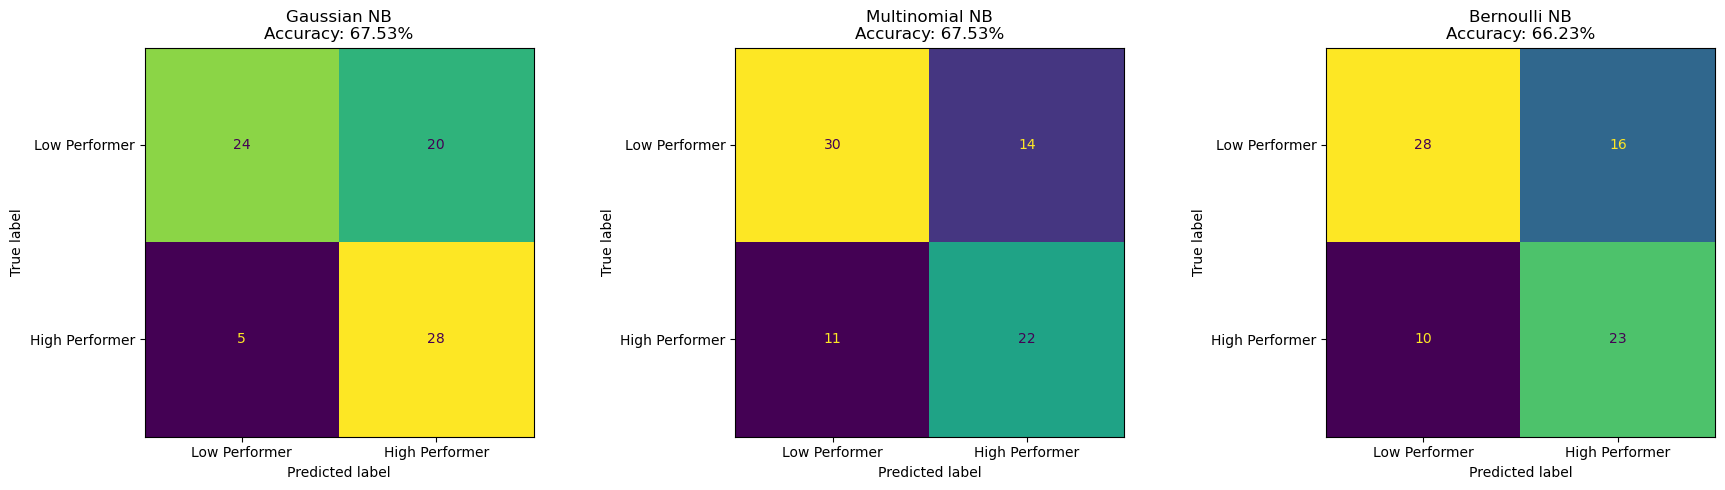

Saved nb_confusion_matrices.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Gaussian NB', gnb_preds, gnb_acc),
    ('Multinomial NB', mnb_preds, mnb_acc),
    ('Bernoulli NB', bnb_preds, bnb_acc)
]

for ax, (name, preds, acc) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Low Performer', 'High Performer'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}')

plt.tight_layout()
plt.savefig('nb_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved nb_confusion_matrices.png")

# Decision Trees
## Data Prep

DT Training set shape: (308, 4)
DT Test set shape: (77, 4)


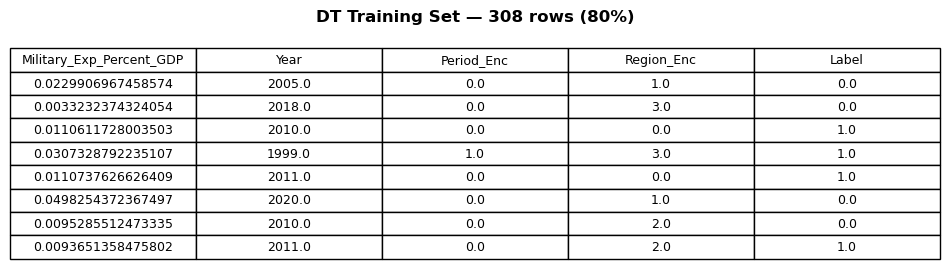

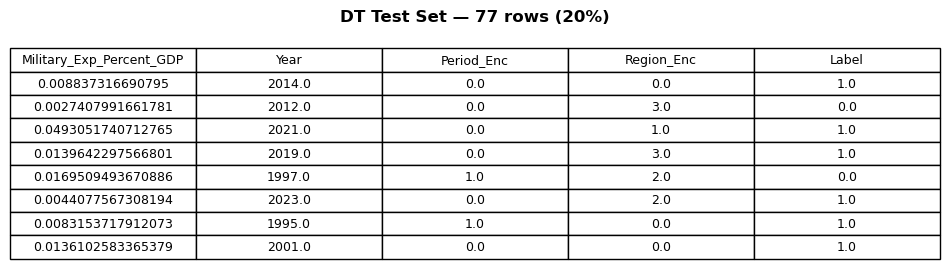

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split


df_dt = pd.read_csv('nb_full_labeled.csv')

X_dt = df_dt.drop(columns=['Label'])
y_dt = df_dt['Label']

# 80/20 split with same random state for reproducibility
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42
)

# Wbsite screenshots
X_train_dt.to_csv('dt_X_train.csv', index=False)
X_test_dt.to_csv('dt_X_test.csv', index=False)

print("DT Training set shape:", X_train_dt.shape)
print("DT Test set shape:", X_test_dt.shape)

# Screenshot of training set
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
train_sample = X_train_dt.head(8).copy()
train_sample['Label'] = y_train_dt.head(8).values
table = ax.table(cellText=train_sample.values,
                 colLabels=train_sample.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
plt.title(f'DT Training Set — {X_train_dt.shape[0]} rows (80%)', fontweight='bold', pad=12)
plt.savefig('dt_training_set_screenshot.png', dpi=200, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
test_sample = X_test_dt.head(8).copy()
test_sample['Label'] = y_test_dt.head(8).values
table = ax.table(cellText=test_sample.values,
                 colLabels=test_sample.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
plt.title(f'DT Test Set — {X_test_dt.shape[0]} rows (20%)', fontweight='bold', pad=12)
plt.savefig('dt_test_set_screenshot.png', dpi=200, bbox_inches='tight')
plt.show()

# 3 DT Models 

Tree 1 (GINI, depth=3) Accuracy: 0.8182
Tree 1 Root Feature: Region_Enc


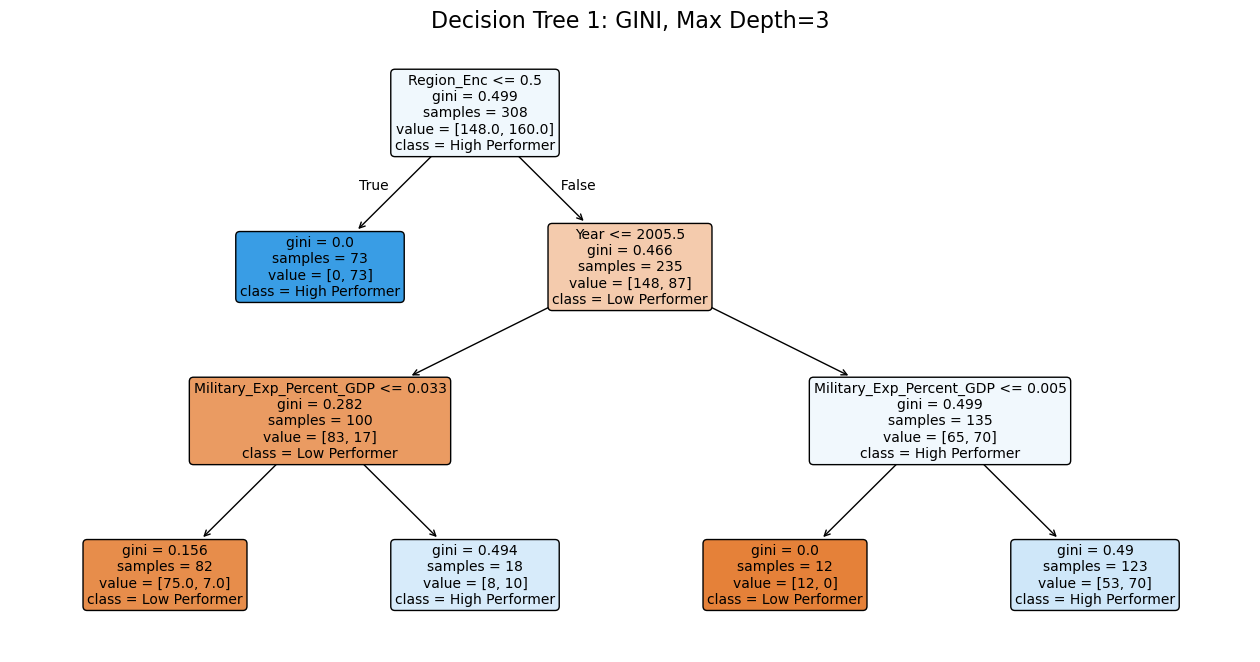

Tree 2 (Entropy, depth=4) Accuracy: 0.8442
Tree 2 Root Feature: Region_Enc


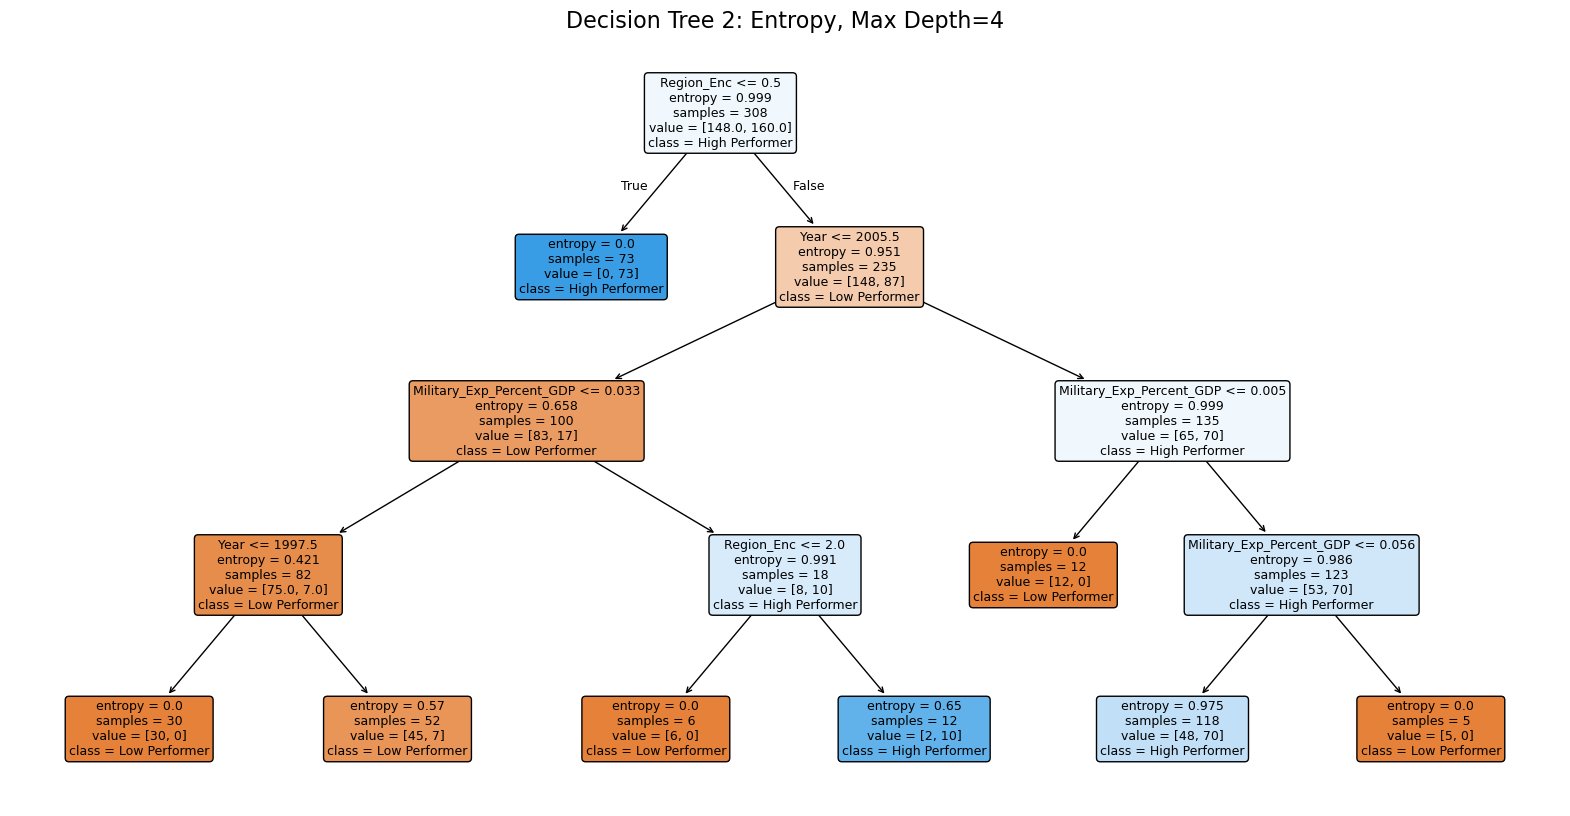

Tree 3 (Forced alt root, depth=4) Accuracy: 0.6883
Tree 3 Root Feature: Year


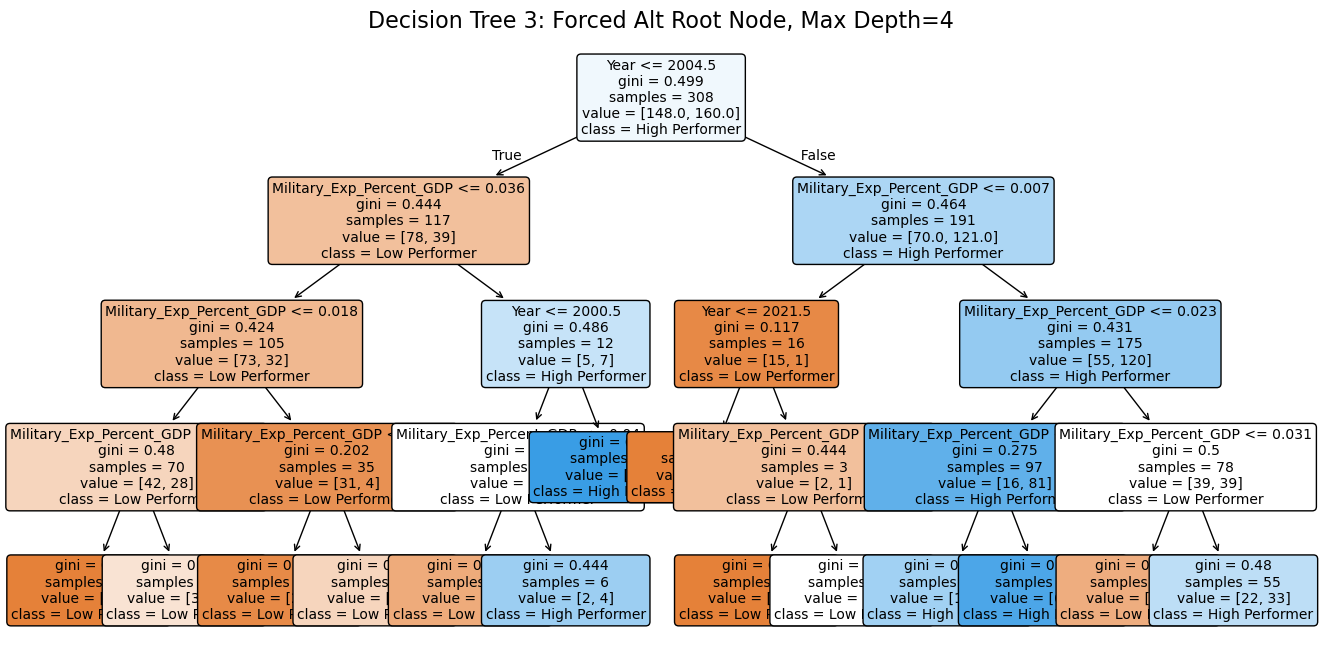

In [7]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

feature_names = X_train_dt.columns.tolist()
class_names = ['Low Performer', 'High Performer']

# ==========================================
# TREE 1: Default GINI, depth=3
# Root node is determined by highest information gain across all features
# ==========================================
dt1 = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt1.fit(X_train_dt, y_train_dt)
dt1_preds = dt1.predict(X_test_dt)
dt1_acc = accuracy_score(y_test_dt, dt1_preds)
print(f"Tree 1 (GINI, depth=3) Accuracy: {dt1_acc:.4f}")
print("Tree 1 Root Feature:", feature_names[dt1.tree_.feature[0]])

plt.figure(figsize=(16, 8))
plot_tree(dt1, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree 1: GINI, Max Depth=3', fontsize=16)
plt.savefig('dt_tree1.png', dpi=200, bbox_inches='tight')
plt.show()

# ==========================================
# TREE 2: Entropy criterion, depth=4
# Entropy typically finds a different root than GINI
# ==========================================
dt2 = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt2.fit(X_train_dt, y_train_dt)
dt2_preds = dt2.predict(X_test_dt)
dt2_acc = accuracy_score(y_test_dt, dt2_preds)
print(f"Tree 2 (Entropy, depth=4) Accuracy: {dt2_acc:.4f}")
print("Tree 2 Root Feature:", feature_names[dt2.tree_.feature[0]])

plt.figure(figsize=(20, 10))
plot_tree(dt2, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree 2: Entropy, Max Depth=4', fontsize=16)
plt.savefig('dt_tree2.png', dpi=200, bbox_inches='tight')
plt.show()

# ==========================================
# TREE 3: Force a different root node by removing the top feature
# This shows what the tree looks like if Region is excluded
# ==========================================
# Find which feature is root of Tree 1
root_feature = feature_names[dt1.tree_.feature[0]]
features_no_root = [f for f in feature_names if f != root_feature]

X_train_alt = X_train_dt[features_no_root]
X_test_alt = X_test_dt[features_no_root]

dt3 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt3.fit(X_train_alt, y_train_alt := y_train_dt)
dt3_preds = dt3.predict(X_test_alt)
dt3_acc = accuracy_score(y_test_dt, dt3_preds)
print(f"Tree 3 (Forced alt root, depth=4) Accuracy: {dt3_acc:.4f}")
print("Tree 3 Root Feature:", features_no_root[dt3.tree_.feature[0]])

plt.figure(figsize=(16, 8))
plot_tree(dt3, feature_names=features_no_root, class_names=class_names,
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree 3: Forced Alt Root Node, Max Depth=4', fontsize=16)
plt.savefig('dt_tree3.png', dpi=200, bbox_inches='tight')
plt.show()

# Results

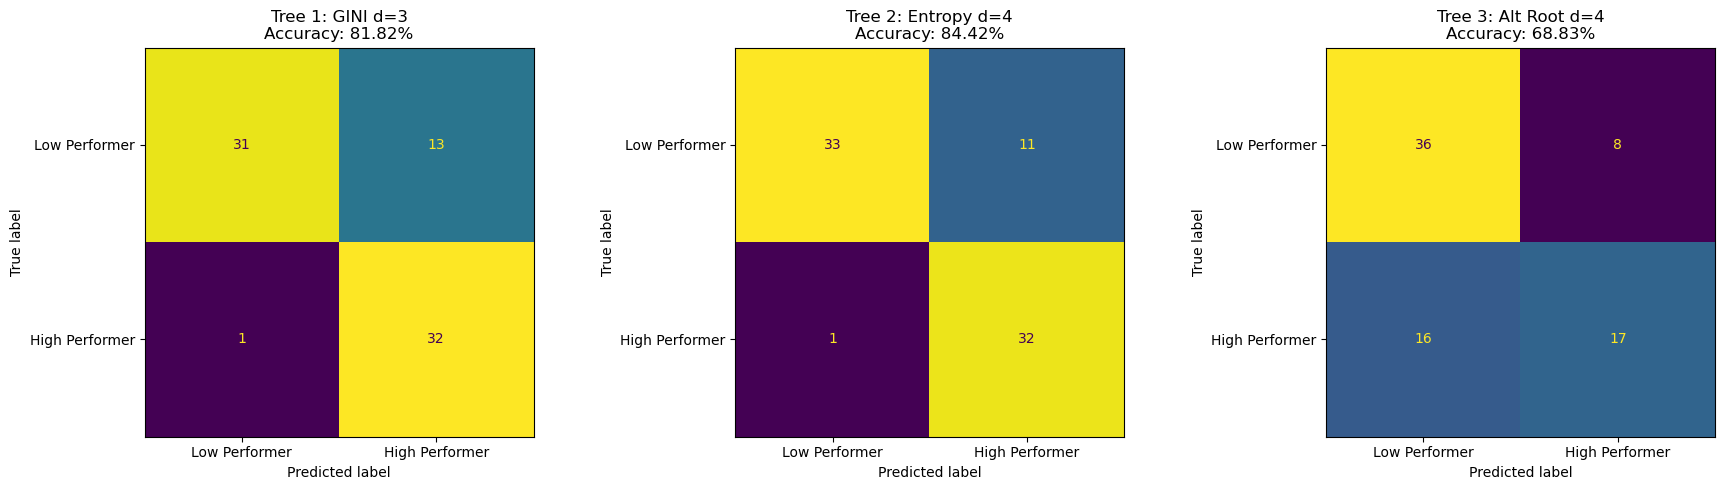

Saved dt_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trees = [
    ('Tree 1: GINI d=3', dt1_preds, dt1_acc),
    ('Tree 2: Entropy d=4', dt2_preds, dt2_acc),
    ('Tree 3: Alt Root d=4', dt3_preds, dt3_acc)
]

for ax, (name, preds, acc) in zip(axes, trees):
    cm = confusion_matrix(y_test_dt, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}')

plt.tight_layout()
plt.savefig('dt_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved dt_confusion_matrices.png")

# Logistic Regression Compared to NB and DT 

Logistic Regression Accuracy: 0.7662
Multinomial NB Accuracy:      0.6753
Decision Tree Accuracy:       0.8442


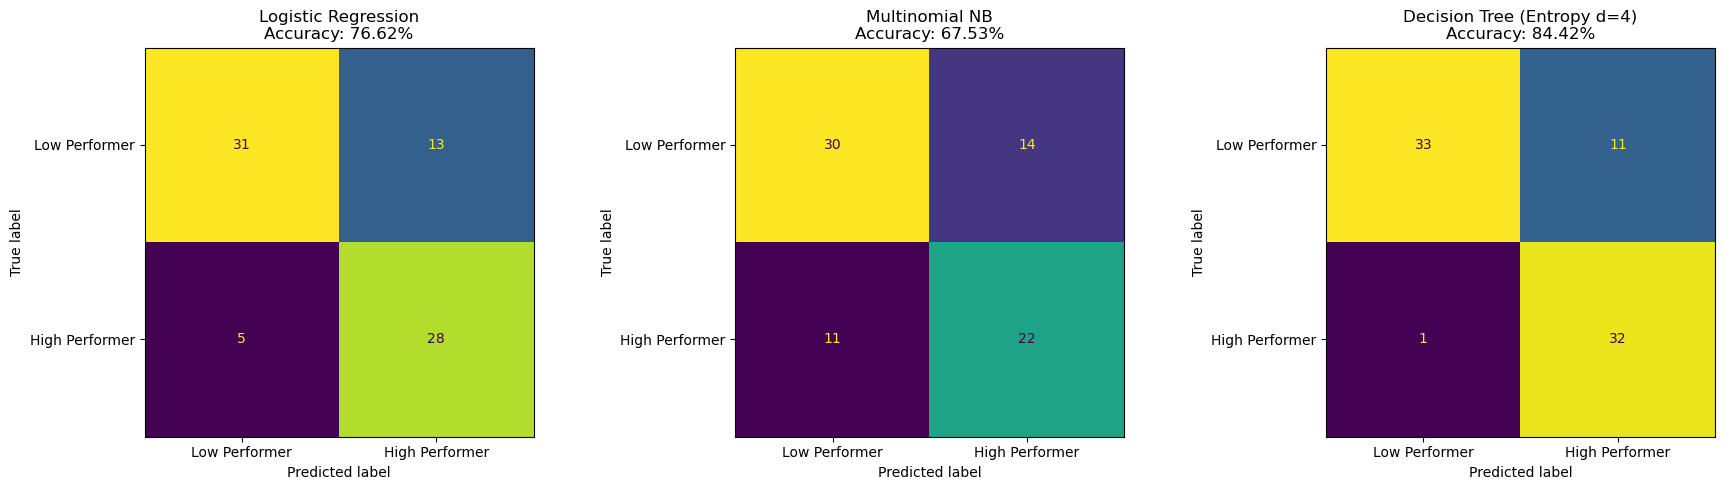

Saved regression_comparison_plot.png


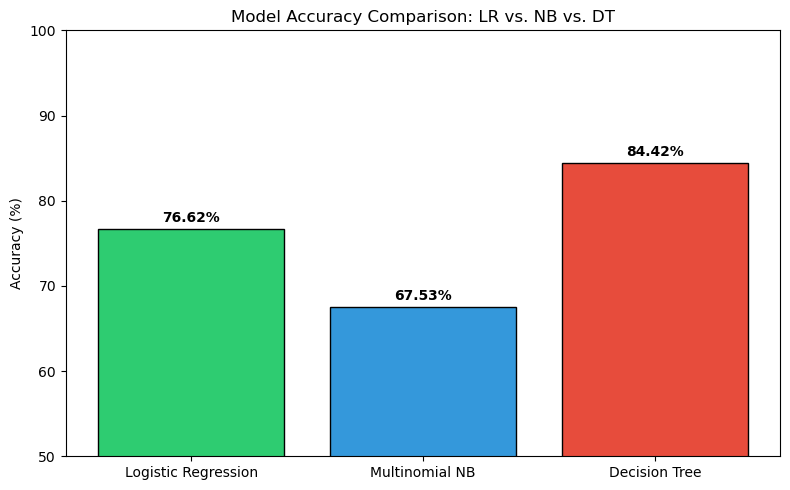

Saved regression_accuracy_bar.png


In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & PREP DATA (same as NB/DT)
# ==========================================
df = pd.read_csv('nb_full_labeled.csv')
X = df.drop(columns=['Label'])
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression needs scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MNB needs non-negative values
X_train_mn = X_train - X_train.min()
X_test_mn = X_test - X_train.min()

# ==========================================
# 2. FIT ALL THREE MODELS
# ==========================================
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)

# Multinomial Naive Bayes
mnb = MultinomialNB()
mnb.fit(X_train_mn, y_train)
mnb_preds = mnb.predict(X_test_mn)
mnb_acc = accuracy_score(y_test, mnb_preds)

# Decision Tree (best performing from earlier)
dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Multinomial NB Accuracy:      {mnb_acc:.4f}")
print(f"Decision Tree Accuracy:       {dt_acc:.4f}")

# ==========================================
# 3. CONFUSION MATRICES SIDE BY SIDE
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Low Performer', 'High Performer']

models = [
    ('Logistic Regression', lr_preds, lr_acc),
    ('Multinomial NB', mnb_preds, mnb_acc),
    ('Decision Tree (Entropy d=4)', dt_preds, dt_acc)
]

for ax, (name, preds, acc) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}')

plt.tight_layout()
plt.savefig('regression_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved regression_comparison_plot.png")

# ==========================================
# 4. BAR CHART COMPARISON
# ==========================================
plt.figure(figsize=(8, 5))
model_names = ['Logistic Regression', 'Multinomial NB', 'Decision Tree']
accuracies = [lr_acc, mnb_acc, dt_acc]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = plt.bar(model_names, [a * 100 for a in accuracies], color=colors, edgecolor='black')
plt.ylim(50, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison: LR vs. NB vs. DT')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('regression_accuracy_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved regression_accuracy_bar.png")